In [14]:
#!pip install scanpy
import scanpy as sc
import os
import glob

!export OPENBLAS_NUM_THREADS=4
os.environ["OPENBLAS_NUM_THREADS"] = "4"

In [15]:
# Parent directory where all samples are located
parent_dir = "/mnt/lun3/processed/LungSingleCell/AshleyMLaughney/StarSoloOut/"

# Find all 'filtered' directories under the parent
base_dirs = glob.glob(os.path.join(parent_dir, "*_STAR", "*Solo.out", "Gene", "filtered"))

print(f"Found {len(base_dirs)} samples.")

Found 122 samples.


In [16]:
import gzip
import shutil
import os
import glob

# Parent directory
parent_dir = "/mnt/lun3/processed/LungSingleCell/AshleyMLaughney/StarSoloOut/"

# Find all 'filtered' folders
filtered_dirs = glob.glob(os.path.join(parent_dir, "*_STAR", "*Solo.out", "Gene", "filtered"))

# Files you want to gzip
files_to_gzip = ["matrix.mtx", "features.tsv", "barcodes.tsv"]

print(f"Found {len(filtered_dirs)} filtered directories.")

# Go through each filtered directory
for folder in filtered_dirs:
    print(f"Processing {folder}...")
    for filename in files_to_gzip:
        file_path = os.path.join(folder, filename)
        gz_path = file_path + ".gz"

        # Only gzip if gz file does not exist
        if os.path.exists(file_path) and not os.path.exists(gz_path):
            with open(file_path, 'rb') as f_in:
                with gzip.open(gz_path, 'wb') as f_out:
                    shutil.copyfileobj(f_in, f_out)
            print(f"  Gzipped {file_path} -> {gz_path}")
        elif not os.path.exists(file_path):
            print(f"  Skipped (file missing): {file_path}")
        else:
            print(f"  Skipped (gz file already exists): {gz_path}")


Found 122 filtered directories.
Processing /mnt/lun3/processed/LungSingleCell/AshleyMLaughney/StarSoloOut/SRR8325995_STAR/SRR8325995Solo.out/Gene/filtered...
  Skipped (gz file already exists): /mnt/lun3/processed/LungSingleCell/AshleyMLaughney/StarSoloOut/SRR8325995_STAR/SRR8325995Solo.out/Gene/filtered/matrix.mtx.gz
  Skipped (gz file already exists): /mnt/lun3/processed/LungSingleCell/AshleyMLaughney/StarSoloOut/SRR8325995_STAR/SRR8325995Solo.out/Gene/filtered/features.tsv.gz
  Skipped (gz file already exists): /mnt/lun3/processed/LungSingleCell/AshleyMLaughney/StarSoloOut/SRR8325995_STAR/SRR8325995Solo.out/Gene/filtered/barcodes.tsv.gz
Processing /mnt/lun3/processed/LungSingleCell/AshleyMLaughney/StarSoloOut/SRR8326022_STAR/SRR8326022Solo.out/Gene/filtered...
  Skipped (gz file already exists): /mnt/lun3/processed/LungSingleCell/AshleyMLaughney/StarSoloOut/SRR8326022_STAR/SRR8326022Solo.out/Gene/filtered/matrix.mtx.gz
  Skipped (gz file already exists): /mnt/lun3/processed/LungSing

KeyboardInterrupt: 

In [69]:
import os
import glob
import pandas as pd

main_folder = "/mnt/lun3/processed/LungSingleCell/AshleyMLaughney/StarSoloOut/"  # <- Update this

# Print for debugging
print("Searching under:", main_folder)

pattern = os.path.join(main_folder, "*_STAR", "*Solo.out", "Gene", "filtered", "barcodes.tsv*")
print("Using pattern:", pattern)

barcode_files = glob.glob(pattern)

if not barcode_files:
    print("❌ No barcodes.tsv files found with the current pattern.")
else:
    total = 0
    for file in barcode_files:
        try:
            print(f"Reading: {file}")
            if file.endswith(".gz"):
                df = pd.read_csv(file, compression="gzip", header=None)
            else:
                df = pd.read_csv(file, header=None)
            total += len(df)
        except Exception as e:
            print(f"Failed to read {file}: {e}")
    print(f"✅ Total barcodes found: {total}")


Searching under: /mnt/lun3/processed/LungSingleCell/AshleyMLaughney/StarSoloOut/
Using pattern: /mnt/lun3/processed/LungSingleCell/AshleyMLaughney/StarSoloOut/*_STAR/*Solo.out/Gene/filtered/barcodes.tsv*
Reading: /mnt/lun3/processed/LungSingleCell/AshleyMLaughney/StarSoloOut/SRR8325995_STAR/SRR8325995Solo.out/Gene/filtered/barcodes.tsv.gz
Reading: /mnt/lun3/processed/LungSingleCell/AshleyMLaughney/StarSoloOut/SRR8325995_STAR/SRR8325995Solo.out/Gene/filtered/barcodes.tsv
Reading: /mnt/lun3/processed/LungSingleCell/AshleyMLaughney/StarSoloOut/SRR8326022_STAR/SRR8326022Solo.out/Gene/filtered/barcodes.tsv.gz
Reading: /mnt/lun3/processed/LungSingleCell/AshleyMLaughney/StarSoloOut/SRR8326022_STAR/SRR8326022Solo.out/Gene/filtered/barcodes.tsv
Reading: /mnt/lun3/processed/LungSingleCell/AshleyMLaughney/StarSoloOut/SRR8326061_STAR/SRR8326061Solo.out/Gene/filtered/barcodes.tsv.gz
Reading: /mnt/lun3/processed/LungSingleCell/AshleyMLaughney/StarSoloOut/SRR8326061_STAR/SRR8326061Solo.out/Gene/filte

In [ ]:
import scanpy as sc

adatas = []

# Parent directory where all samples are located
parent_dir = "/mnt/lun3/processed/LungSingleCell/AshleyMLaughney/StarSoloOut/"

# Find all 'filtered' directories
base_dirs = glob.glob(os.path.join(parent_dir, "*_STAR", "*Solo.out", "Gene", "filtered"))


for d in base_dirs:
    # Extract sample name from folder path
    sample_name = os.path.basename(os.path.dirname(os.path.dirname(os.path.dirname(d))))
    
    print(f"Loading sample: {sample_name} from {d}")
    
    adata = sc.read_10x_mtx(
        d,
        var_names="gene_symbols",  # use 'features.tsv' 2nd column
        make_unique=True
    )
    
    adata.obs["sample"] = sample_name  # Tag each cell with its sample name
    adatas.append(adata)

# Merge everything
adata_merged = adatas[0].concatenate(adatas[1:], batch_key="sample", batch_categories=[a.obs["sample"][0] for a in adatas])

print(adata_merged)


In [ ]:
# Parent directory where all samples are located
parent_dir = "/mnt/lun3/processed/LungSingleCell/AshleyMLaughney/StarSoloOut/"

# Find all 'filtered' directories
base_dirs = glob.glob(os.path.join(parent_dir, "*_STAR", "*Solo.out", "Gene", "filtered"))



In [ ]:
#read PeakATail_wd/data/20250507_laughney_metadata.csv
import pandas as pd
metadata = pd.read_csv("/home/biolab/Projects/PeakATail_wd/data/20250507_laughney_metadata.csv", index_col=0)
#to match the naming with the adata_mergerd
metadata.index = metadata.index + "_STAR"
metadata


,Assay.Type,AvgSpotLen,Bases,BioProject,BioSample,Bytes,Center.Name,chemotherapy,diagnosis,Experiment,...,create_date,Sample.Name,source_name,SRA.Study,Stage,tissue,patient_id,smoking,TNM_stage,mutations
SRR8325947_STAR,RNA-Seq,124,1686591456,PRJNA510251,SAMN10600753,1003230736,GEO,No,Lung Adenocarcinoma,SRX5137765,...,2018-12-16T13:02:00Z,GSM3516662,Patient primary lung adenocarcinoma,SRP173552,1A,Patient primary lung adenocarcinoma,MSK-LX653,never,T1bN0M0,"EGFR,KMT2D,U2AF1,RET"
SRR8325948_STAR,RNA-Seq,124,1692384488,PRJNA510251,SAMN10600753,1009650669,GEO,No,Lung Adenocarcinoma,SRX5137765,...,2018-12-16T13:02:00Z,GSM3516662,Patient primary lung adenocarcinoma,SRP173552,1A,Patient primary lung adenocarcinoma,MSK-LX653,never,T1bN0M0,"EGFR,KMT2D,U2AF1,RET"
SRR8325949_STAR,RNA-Seq,124,1692174928,PRJNA510251,SAMN10600753,1010633296,GEO,No,Lung Adenocarcinoma,SRX5137765,...,2018-12-16T13:03:00Z,GSM3516662,Patient primary lung adenocarcinoma,SRP173552,1A,Patient primary lung adenocarcinoma,MSK-LX653,never,T1bN0M0,"EGFR,KMT2D,U2AF1,RET"
SRR8325950_STAR,RNA-Seq,124,1697285712,PRJNA510251,SAMN10600753,1011215275,GEO,No,Lung Adenocarcinoma,SRX5137765,...,2018-12-16T13:03:00Z,GSM3516662,Patient primary lung adenocarcinoma,SRP173552,1A,Patient primary lung adenocarcinoma,MSK-LX653,never,T1bN0M0,"EGFR,KMT2D,U2AF1,RET"
SRR8325951_STAR,RNA-Seq,124,1707574860,PRJNA510251,SAMN10600753,1020759380,GEO,No,Lung Adenocarcinoma,SRX5137765,...,2018-12-16T13:02:00Z,GSM3516662,Patient primary lung adenocarcinoma,SRP173552,1A,Patient primary lung adenocarcinoma,MSK-LX653,never,T1bN0M0,"EGFR,KMT2D,U2AF1,RET"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SRR8326064_STAR,RNA-Seq,124,1804221576,PRJNA510251,SAMN10600739,1093013212,GEO,No,non-tumour involved lung,SRX5137778,...,2018-12-16T13:07:00Z,GSM3516676,Patient adjacent non-tumour involved lung,SRP173552,na,Patient adjacent non-tumour involved lung,MSK-LX685,never,T1aN0M0,NaN
SRR8326065_STAR,RNA-Seq,124,1813066000,PRJNA510251,SAMN10600739,1094279615,GEO,No,non-tumour involved lung,SRX5137778,...,2018-12-16T13:08:00Z,GSM3516676,Patient adjacent non-tumour involved lung,SRP173552,na,Patient adjacent non-tumour involved lung,MSK-LX685,never,T1aN0M0,NaN
SRR8326066_STAR,RNA-Seq,124,1821684248,PRJNA510251,SAMN10600739,1097595316,GEO,No,non-tumour involved lung,SRX5137778,...,2018-12-16T13:08:00Z,GSM3516676,Patient adjacent non-tumour involved lung,SRP173552,na,Patient adjacent non-tumour involved lung,MSK-LX685,never,T1aN0M0,NaN
SRR8326067_STAR,RNA-Seq,124,15673007156,PRJNA510251,SAMN10600738,9374120804,GEO,Yes,Lung Adenocarcinoma,SRX5137779,...,2018-12-16T13:44:00Z,GSM3516677,Patient primary lung adenocarcinoma metastasis...,SRP173552,IV,Patient primary lung adenocarcinoma metastasis...,MSK-LX699,yes,T2N2M1,"KRAS,TP53"


In [ ]:
# Merge metadata with adata_merged
metadata["sample"] = metadata.index
# Merge the metadata with the adata_merged
for col in metadata.columns:
    adata_merged.obs[col] = adata_merged.obs["sample"].map(metadata[col])
# Check if the merge was successful
adata_merged.obs

NameError: name 'adata_merged' is not defined

In [ ]:
#save adata as h5ad
adata_merged.write("/home/biolab/Projects/PeakATail_wd/data/20250507_laughney_adata_merged.h5ad")

In [63]:
#import gzip
#import shutil
#import os
#import glob
#import scanpy as sc
adata_merged = sc.read_h5ad("/mnt/ssd1/Projects/PeakATail_wd/data/20250507_laughney_adata_merged.h5ad")

In [64]:
adata_merged

AnnData object with n_obs × n_vars = 201078 × 60676
    obs: 'sample', 'Assay.Type', 'AvgSpotLen', 'Bases', 'BioProject', 'BioSample', 'Bytes', 'Center.Name', 'chemotherapy', 'diagnosis', 'Experiment', 'GEO_Accession..exp.', 'Instrument', 'LibraryLayout', 'LibrarySelection', 'LibrarySource', 'Organism', 'Platform', 'ReleaseDate', 'create_date', 'Sample.Name', 'source_name', 'SRA.Study', 'Stage', 'tissue', 'patient_id', 'smoking', 'TNM_stage', 'mutations'
    var: 'gene_ids', 'feature_types'

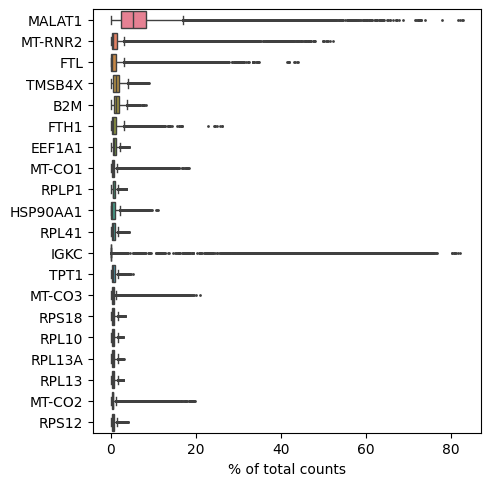

AnnData object with n_obs × n_vars = 200268 × 30974
    obs: 'sample', 'Assay.Type', 'AvgSpotLen', 'Bases', 'BioProject', 'BioSample', 'Bytes', 'Center.Name', 'chemotherapy', 'diagnosis', 'Experiment', 'GEO_Accession..exp.', 'Instrument', 'LibraryLayout', 'LibrarySelection', 'LibrarySource', 'Organism', 'Platform', 'ReleaseDate', 'create_date', 'Sample.Name', 'source_name', 'SRA.Study', 'Stage', 'tissue', 'patient_id', 'smoking', 'TNM_stage', 'mutations', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'

In [20]:
#preprocessing
sc.pl.highest_expr_genes(adata_merged, n_top=20)
sc.pp.filter_cells(adata_merged, min_genes=200)
#usually its min_cells 3 but they did 10 in the paper
sc.pp.filter_genes(adata_merged, min_cells=10)
adata_merged

In [ ]:
adata_merged

AnnData object with n_obs × n_vars = 200268 × 30974
    obs: 'sample', 'Assay.Type', 'AvgSpotLen', 'Bases', 'BioProject', 'BioSample', 'Bytes', 'Center.Name', 'chemotherapy', 'diagnosis', 'Experiment', 'GEO_Accession..exp.', 'Instrument', 'LibraryLayout', 'LibrarySelection', 'LibrarySource', 'Organism', 'Platform', 'ReleaseDate', 'create_date', 'Sample.Name', 'source_name', 'SRA.Study', 'Stage', 'tissue', 'patient_id', 'smoking', 'TNM_stage', 'mutations', 'n_genes'
    var: 'gene_ids', 'feature_types', 'n_cells'

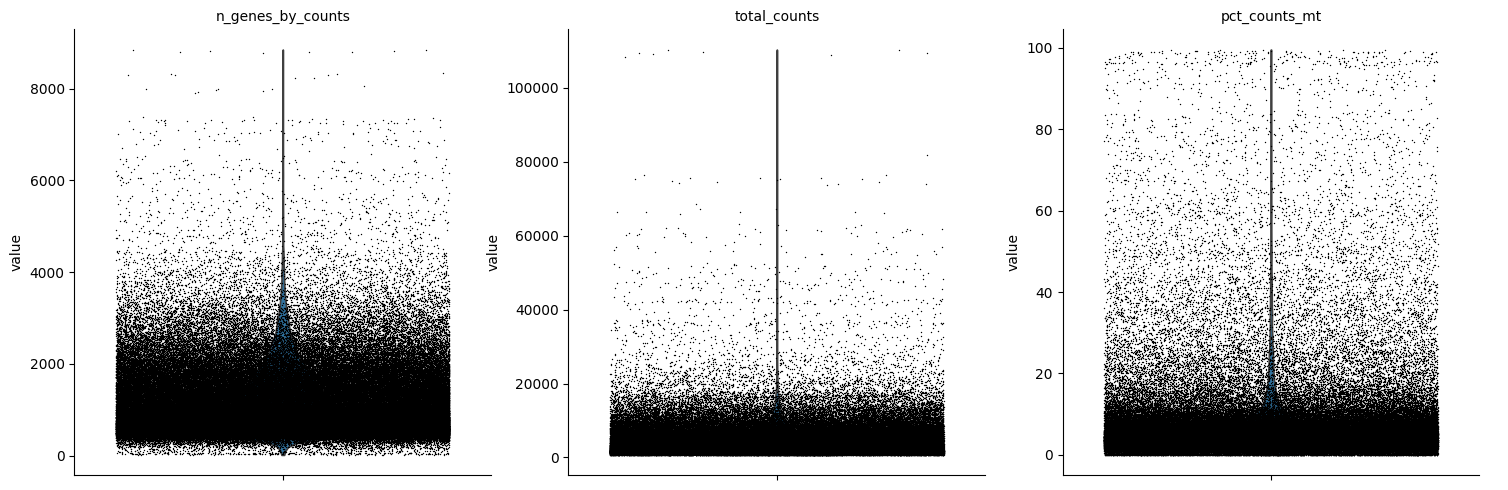

In [19]:
adata_merged.var["mt"] = adata_merged.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(
    adata_merged, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True
)
sc.pl.violin(
    adata_merged,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)
#adata_merged

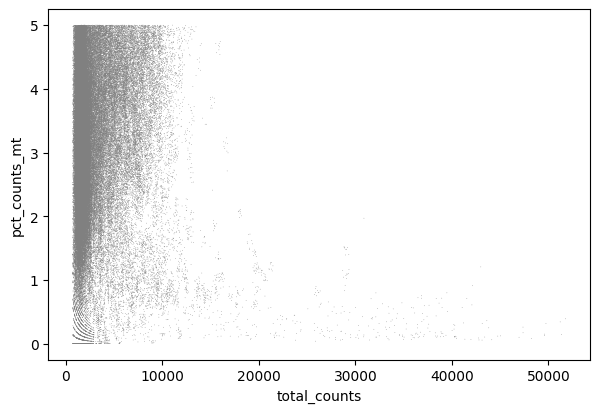

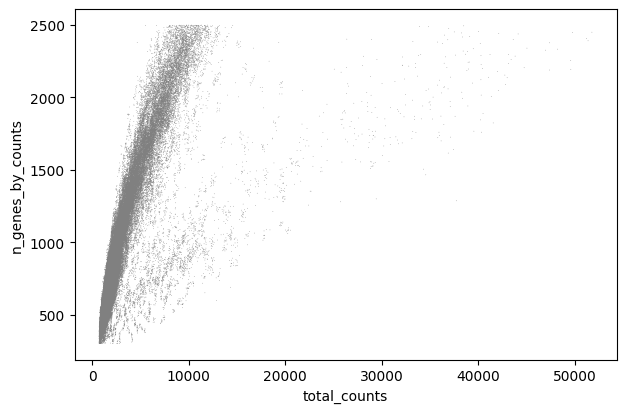

In [22]:
sc.pl.scatter(adata_merged, x="total_counts", y="pct_counts_mt")
sc.pl.scatter(adata_merged, x="total_counts", y="n_genes_by_counts")

In [59]:
adata_merged.obs.groupby('sample').size()

/tmp/ipykernel_2028935/3528368793.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata_merged.obs.groupby('sample').size()


sample
SRR8325995_STAR     294
SRR8326022_STAR     300
SRR8326061_STAR     417
SRR8325989_STAR     405
SRR8325955_STAR     877
                   ... 
SRR8326053_STAR     780
SRR8325973_STAR     388
SRR8326051_STAR     767
SRR8325964_STAR     198
SRR8326067_STAR    1960
Length: 122, dtype: int64

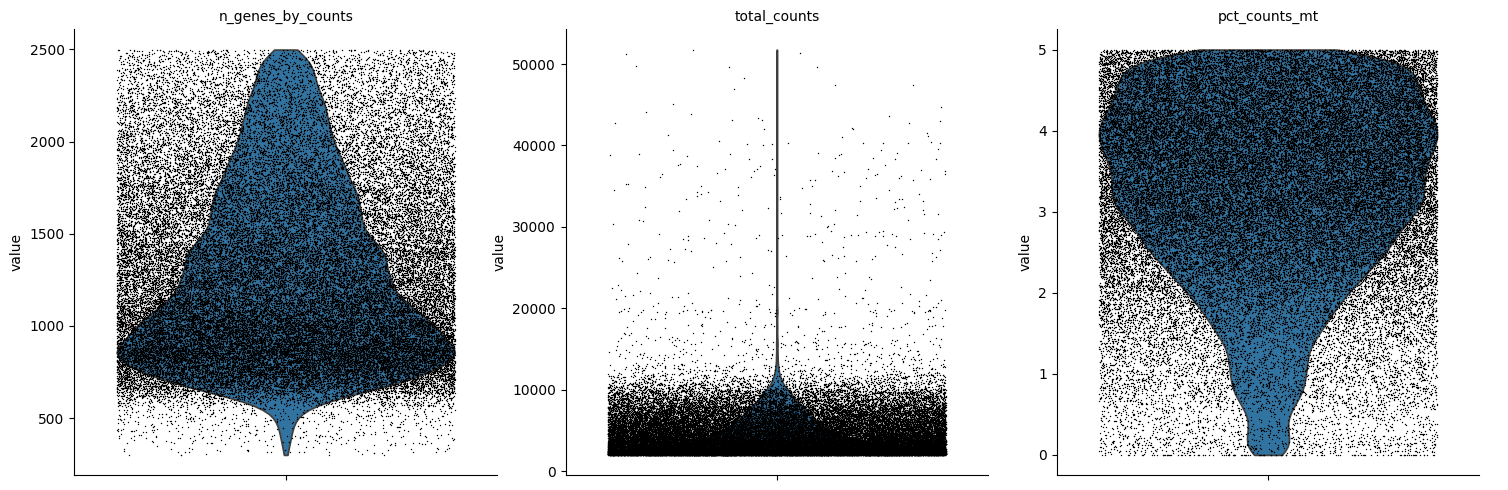

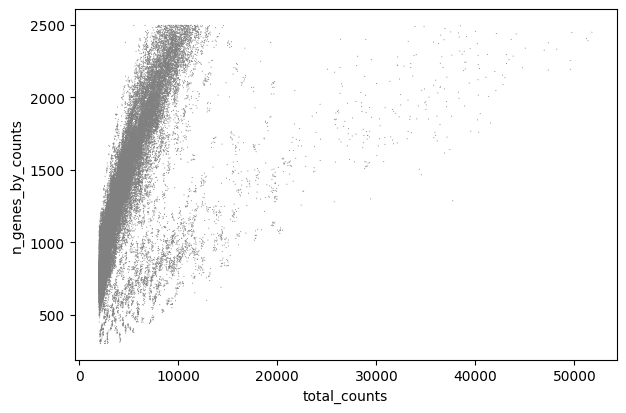

AnnData object with n_obs × n_vars = 56043 × 30974
    obs: 'sample', 'Assay.Type', 'AvgSpotLen', 'Bases', 'BioProject', 'BioSample', 'Bytes', 'Center.Name', 'chemotherapy', 'diagnosis', 'Experiment', 'GEO_Accession..exp.', 'Instrument', 'LibraryLayout', 'LibrarySelection', 'LibrarySource', 'Organism', 'Platform', 'ReleaseDate', 'create_date', 'Sample.Name', 'source_name', 'SRA.Study', 'Stage', 'tissue', 'patient_id', 'smoking', 'TNM_stage', 'mutations', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'

In [23]:
adata_merged = adata_merged[adata_merged.obs.n_genes_by_counts < 2500, :]
adata_merged = adata_merged[adata_merged.obs.n_genes_by_counts > 300, :]
adata_merged = adata_merged[adata_merged.obs.total_counts >2000, :]
adata_merged= adata_merged[adata_merged.obs.pct_counts_mt < 5, :].copy()

sc.pp.calculate_qc_metrics(
    adata_merged, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True
)
sc.pl.violin(
    adata_merged,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)
sc.pl.scatter(adata_merged, x="total_counts", y="n_genes_by_counts")
adata_merged



In [62]:
#normalization
sc.pp.normalize_total(adata_merged, target_sum=1e4)

sc.pp.log1p(adata_merged)

#highly variable genes
sc.pp.highly_variable_genes(adata_merged, min_mean=0.0125, max_mean=3, min_disp=0.5)

sc.pl.highly_variable_genes(adata_merged)

/home/ebrukocakaya/anaconda3/lib/python3.9/site-packages/scanpy/preprocessing/_normalization.py:234: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))
/home/ebrukocakaya/anaconda3/lib/python3.9/site-packages/scanpy/preprocessing/_simple.py:385: RuntimeWarning: invalid value encountered in log1p
  np.log1p(X, out=X)


ValueError: Bin edges must be unique: Index([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan],
      dtype='float64').
You can drop duplicate edges by setting the 'duplicates' kwarg

In [25]:
#adata_merged.raw = adata_merged.copy()

adata_merged = adata_merged[:, adata_merged.var.highly_variable]


In [26]:
sc.pp.regress_out(adata_merged, ["total_counts", "pct_counts_mt"])

/home/ebrukocakaya/anaconda3/lib/python3.9/site-packages/scanpy/preprocessing/_simple.py:668: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [27]:
sc.pp.scale(adata_merged, max_value=10)

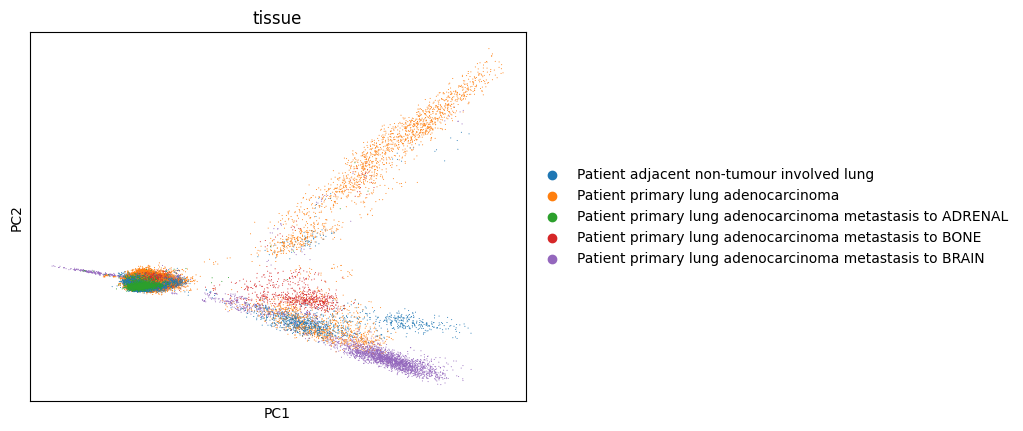

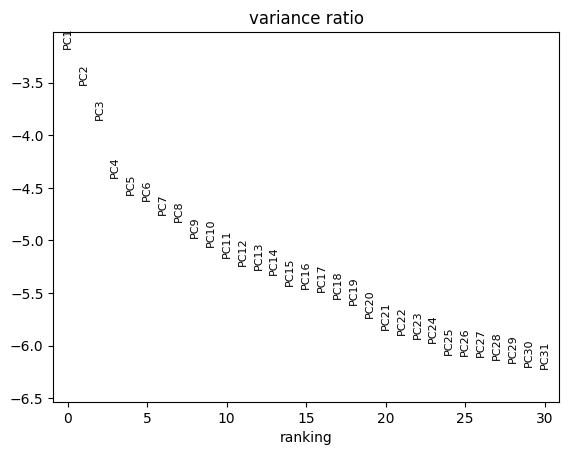

In [31]:
#PCA
sc.tl.pca(adata_merged, svd_solver="arpack")
sc.pl.pca(adata_merged, color= "tissue")
sc.pl.pca_variance_ratio(adata_merged, log=True)

In [ ]:
#!pip3 install igraph
#!pip3 install leidenalg

sc.pp.neighbors(adata_merged, n_neighbors=10, n_pcs=15)
sc.tl.leiden(adata_merged, key_added="leiden")

sc.tl.umap(adata_merged)

#sc.pl.umap(adata_merged, color=["CD68", "CD80", "CD38", "CD86"])

/home/ebrukocakaya/anaconda3/lib/python3.9/site-packages/sklearn/manifold/_spectral_embedding.py:273: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/home/ebrukocakaya/anaconda3/lib/python3.9/site-packages/sklearn/manifold/_spectral_embedding.py:273: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


KeyError: 'Could not find key CD68 in .var_names or .obs.columns.'

<Figure size 2911.2x480 with 0 Axes>

In [42]:
#sc.tl.leiden(
#    adata_merged,
#    resolution=0.9,
 #   random_state=0,
  #  flavor="igraph",
   # n_iterations=2,
    #directed=False,)

#sc.pl.umap(adata_merged, color=["mutations", "diagnosis", "Stage","tissue"])
#sc.pl.umap(adata_merged, color=["CD68", "CD80", "CD38", "CD86"])
#sc.pl.umap(adata_merged, color=["CD68", "CD80", "CD38", "CD86"])

In [71]:
#sc.pl.umap(adata_merged, color=["leiden"])
adata_merged

AnnData object with n_obs × n_vars = 201078 × 60676
    obs: 'sample', 'Assay.Type', 'AvgSpotLen', 'Bases', 'BioProject', 'BioSample', 'Bytes', 'Center.Name', 'chemotherapy', 'diagnosis', 'Experiment', 'GEO_Accession..exp.', 'Instrument', 'LibraryLayout', 'LibrarySelection', 'LibrarySource', 'Organism', 'Platform', 'ReleaseDate', 'create_date', 'Sample.Name', 'source_name', 'SRA.Study', 'Stage', 'tissue', 'patient_id', 'smoking', 'TNM_stage', 'mutations'
    var: 'gene_ids', 'feature_types'

In [ ]:
sc.tl.rank_genes_groups(adata_merged, "leiden", method="t-test")
sc.pl.rank_genes_groups(adata_merged, n_genes=25, sharey=False)



In [50]:
adata_merged.obs

,sample,Assay.Type,AvgSpotLen,Bases,BioProject,BioSample,Bytes,Center.Name,chemotherapy,diagnosis,...,patient_id,smoking,TNM_stage,mutations,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,n_genes,leiden
AAACCTGAGTTTCCTT-SRR8325995_STAR,SRR8325995_STAR,RNA-Seq,124,2003301592,PRJNA510251,SAMN10600747,1198932274,GEO,Yes,Lung Adenocarcinoma,...,MSK-LX255B,yes,T2N1M1,"EGFR,TP53",1484,4500.0,59.0,1.311111,1485,71
AAACCTGGTTTGACTG-SRR8325995_STAR,SRR8325995_STAR,RNA-Seq,124,2003301592,PRJNA510251,SAMN10600747,1198932274,GEO,Yes,Lung Adenocarcinoma,...,MSK-LX255B,yes,T2N1M1,"EGFR,TP53",984,2883.0,141.0,4.890739,984,5
AAACGGGAGGAGCGTT-SRR8325995_STAR,SRR8325995_STAR,RNA-Seq,124,2003301592,PRJNA510251,SAMN10600747,1198932274,GEO,Yes,Lung Adenocarcinoma,...,MSK-LX255B,yes,T2N1M1,"EGFR,TP53",530,2299.0,0.0,0.000000,530,52
AAACGGGGTCATCCCT-SRR8325995_STAR,SRR8325995_STAR,RNA-Seq,124,2003301592,PRJNA510251,SAMN10600747,1198932274,GEO,Yes,Lung Adenocarcinoma,...,MSK-LX255B,yes,T2N1M1,"EGFR,TP53",1268,3452.0,134.0,3.881808,1268,33
AAAGCAAGTTGGTTTG-SRR8325995_STAR,SRR8325995_STAR,RNA-Seq,124,2003301592,PRJNA510251,SAMN10600747,1198932274,GEO,Yes,Lung Adenocarcinoma,...,MSK-LX255B,yes,T2N1M1,"EGFR,TP53",1295,3499.0,70.0,2.000571,1296,64
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGGTTAGGATGGTC-SRR8326067_STAR,SRR8326067_STAR,RNA-Seq,124,15673007156,PRJNA510251,SAMN10600738,9374120804,GEO,Yes,Lung Adenocarcinoma,...,MSK-LX699,yes,T2N2M1,"KRAS,TP53",1736,4954.0,98.0,1.978199,1738,11
TTTGGTTCACCGATAT-SRR8326067_STAR,SRR8326067_STAR,RNA-Seq,124,15673007156,PRJNA510251,SAMN10600738,9374120804,GEO,Yes,Lung Adenocarcinoma,...,MSK-LX699,yes,T2N2M1,"KRAS,TP53",1491,6054.0,266.0,4.393789,1491,5
TTTGGTTTCGGAGGTA-SRR8326067_STAR,SRR8326067_STAR,RNA-Seq,124,15673007156,PRJNA510251,SAMN10600738,9374120804,GEO,Yes,Lung Adenocarcinoma,...,MSK-LX699,yes,T2N2M1,"KRAS,TP53",1847,5587.0,100.0,1.789869,1847,16
TTTGTCACAAAGTGCG-SRR8326067_STAR,SRR8326067_STAR,RNA-Seq,124,15673007156,PRJNA510251,SAMN10600738,9374120804,GEO,Yes,Lung Adenocarcinoma,...,MSK-LX699,yes,T2N2M1,"KRAS,TP53",1265,3620.0,140.0,3.867404,1265,11


/tmp/ipykernel_2028935/480356844.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_genes = adata_merged.obs.groupby('leiden')['pct_counts_mt'].mean().reset_index()
/tmp/ipykernel_2028935/480356844.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


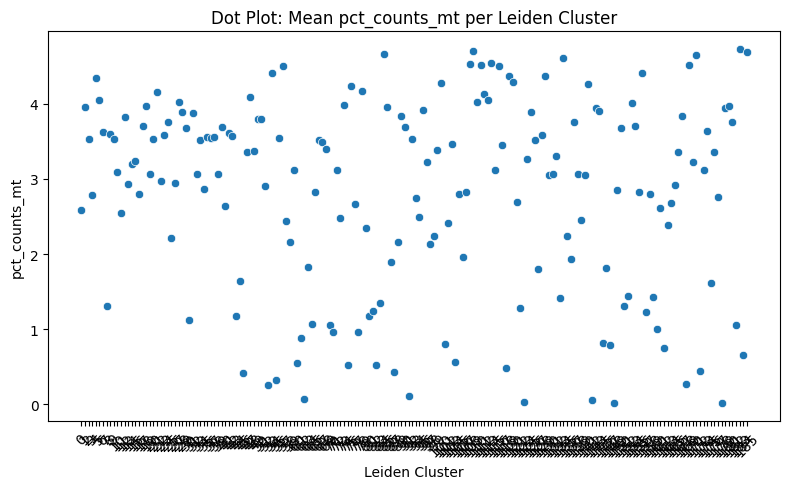

In [56]:

# Prepare the data
mean_genes = adata_merged.obs.groupby('leiden')['pct_counts_mt'].mean().reset_index()
mean_genes['leiden'] = mean_genes['leiden'].astype(str)

# Dot plot (strip-like but scalable)
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=mean_genes,
    x='leiden',
    y='pct_counts_mt',
    palette='viridis',
    legend=False,
    sizes=(100, 1000)
)

plt.title('Dot Plot: Mean pct_counts_mt per Leiden Cluster')
plt.xlabel('Leiden Cluster')
plt.ylabel('pct_counts_mt')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [ ]:
adata_merged.write("/home/biolab/Projects/PeakATail_wd/data/20250507_laughney_adata_merged_processed.h5ad")

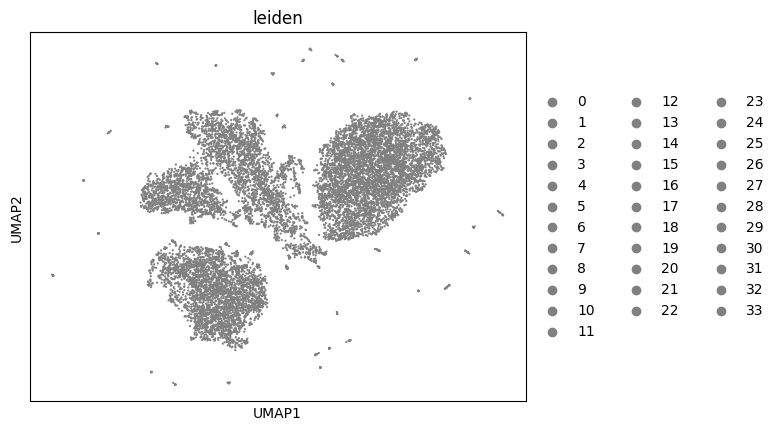

In [ ]:
data = adata_merged

# Make sure leiden is a string (to match properly)
data.obs['leiden'] = data.obs['leiden'].astype(str)

# Get the first 20 unique leiden clusters (sorted as strings)
first_20_clusters = sorted(data.obs['leiden'].unique())[:20]

# Subset the AnnData object
adata_subset = data[data.obs['leiden'].isin(first_20_clusters)].copy()


sc.pp.neighbors(adata_subset, n_neighbors=10, n_pcs=15)
sc.tl.leiden(adata_subset, key_added="leiden")

sc.tl.umap(adata_subset)
sc.pl.umap(adata_subset, color=["leiden"])




In [ ]:
#low res leiden
#adata_2 = adata_merged
sc.pp.neighbors(adata_2, n_neighbors=30, n_pcs=31)
sc.tl.leiden(adata_2, resolution=0.2)  # lower resolution (default is usually 1.0)
sc.tl.paga(adata_2, groups="leiden")

sc.pl.paga(adata_2, plot=False)  # remove `plot=False` if you want to see the coarse-grained graph
sc.tl.umap(adata_2, init_pos='paga')

sc.tl.umap(adata_2)
sc.pl.umap(adata_2, color=["CST3", "NKG7", "PPBP"])

sc.pl.umap(adata_2, color=["mutations", "diagnosis", "Stage","tissue"])


In [ ]:
sc.pl.umap(adata_2, color=["mutations", "diagnosis"], save ="20250508_laughney_lowres_mutations.pdf")
sc.pl.umap(adata_2, color=["Stage","tissue"], save="20250508_laughney_lowres_stage.pdf") 

In [ ]:
sc.pl.umap(adata_2, color=["leiden"], save="20250508_laughney_lowres_leiden.pdf")

In [ ]:
adata_2.write("/home/biolab/Projects/PeakATail_wd/data/20250508_laughney_adata_merged_processed_low_res.h5ad")